# Tool Call Error Analysis (SQL)
Uses DuckDB for SQL-based querying of inference results. Each section has a query you can tweak to explore examples.

In [1]:
import json, duckdb

DATA_PATH = "../output/inference/pd_fin_llm_tool_passing_guard_financial_tool_calling.jsonl"

with open(DATA_PATH) as f:
    samples = [json.loads(line) for line in f]

def parse_tool(text):
    try:
        d = json.loads(text)
        if isinstance(d, dict) and "name" in d:
            return d
    except Exception:
        pass
    return None

rows = []
for s in samples:
    ptc = parse_tool(s["prediction"])
    rtc = parse_tool(s["reference"])
    pred_params = json.dumps(ptc.get("parameters", {}), sort_keys=True) if ptc else None
    ref_params = json.dumps(rtc.get("parameters", {}), sort_keys=True) if rtc else None

    # per-key diffs
    missing_keys = extra_keys = wrong_keys = None
    if ptc and rtc:
        pp, rp = ptc.get("parameters", {}), rtc.get("parameters", {})
        missing_keys = sorted(set(rp) - set(pp)) or None
        extra_keys = sorted(set(pp) - set(rp)) or None
        wrong_keys = sorted(k for k in set(pp) & set(rp) if pp[k] != rp[k]) or None

    rows.append({
        "idx": s["index"],
        "question": s["question"],
        "pred_raw": s["prediction"],
        "ref_raw": s["reference"],
        "pred_is_tool": ptc is not None,
        "ref_is_tool": rtc is not None,
        "pred_name": ptc["name"] if ptc else None,
        "ref_name": rtc["name"] if rtc else None,
        "pred_params": pred_params,
        "ref_params": ref_params,
        "missing_keys": json.dumps(missing_keys) if missing_keys else None,
        "extra_keys": json.dumps(extra_keys) if extra_keys else None,
        "wrong_value_keys": json.dumps(wrong_keys) if wrong_keys else None,
    })

import pandas as pd
con = duckdb.connect()
df_rows = pd.DataFrame(rows)
con.execute("CREATE TABLE results AS SELECT * FROM df_rows")
con.sql("SELECT count(*) AS total FROM results").show()

┌───────┐
│ total │
│ int64 │
├───────┤
│   472 │
└───────┘



## Helper to run queries

In [2]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

def q(sql):
    return con.sql(sql).df()

## 1. Call-Type Confusion Matrix

In [3]:
q("""
SELECT
    CASE WHEN ref_is_tool THEN 'tool' ELSE 'text' END AS reference,
    CASE WHEN pred_is_tool THEN 'tool' ELSE 'text' END AS prediction,
    count(*) AS cnt
FROM results
GROUP BY 1, 2
ORDER BY 1, 2
""")

,reference,prediction,cnt
0,text,text,225
1,text,tool,17
2,tool,text,3
3,tool,tool,227


## 2. Missed Tool Calls (should call tool, gave text)

In [4]:
q("""
SELECT idx, question, ref_raw AS expected, pred_raw AS got
FROM results
WHERE ref_is_tool AND NOT pred_is_tool
""")

,idx,question,expected,got
0,75,Can you give me some tips on comparing what I spend on groceries vs. dining out? I want to see where I can save.,"{""name"": ""show_pie_chart"", ""parameters"": {""data_type"": ""spending"", ""time_range"": ""this_month"", ""group_by"": ""category"", ""categories"": [""Groceries"", ""Restaurants""], ""limit"": 2}}","To compare your spending on groceries versus dining out, we can create a pie chart showing the breakdown of your spending in these categories. This will help you visualize where you might be able to save. Would you like to proceed with this analysis?"
1,309,How much have I paid towards my car loan since I took it out?,"{""name"": ""show_line_chart"", ""parameters"": {""chart_type"": ""cash_flow"", ""time_range"": ""this_year"", ""by_account"": false}}","Sorry, I cannot help with this."
2,428,How can I keep track of my balance and cash flow more easily?,"{""name"": ""show_line_chart"", ""parameters"": {""chart_type"": ""balance"", ""time_range"": ""this_month"", ""by_account"": false}}","To keep track of your balance and cash flow more easily, you can create a line chart showing your balance over time and a stacked bar chart for your cash flow. This will give you a clear visual representation of how your balance changes and where your money is coming from and going. Would you like to proceed with this?"


## 3. Hallucinated Tool Calls (should give text, called tool)

In [5]:
q("""
SELECT idx, question, pred_name, pred_params
FROM results
WHERE NOT ref_is_tool AND pred_is_tool
""")

,idx,question,pred_name,pred_params
0,20,Is there a good way to visualize my yearly income and expenses?,show_stacked_bar_chart,"{""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""time_range"": ""this_year""}"
1,22,Is it possible to break down my monthly expenses into essential and non-essential spending?,show_pie_chart,"{""categories"": [""Groceries"", ""Public transport"", ""Fuel"", ""Rent/Mortgage"", ""Utilities"", ""Clothing & Shoes"", ""Eating out"", ""Entertainment"", ""Hobbies"", ""Subscriptions"", ""Insurance"", ""Bank fees"", ""Loans"", ""Miscellaneous""], ""data_type"": ""spending"", ""group_by"": ""category"", ""time_range"": ""this_month""}"
2,40,I want to compare my debts by interest rate. Can you show me a chart?,show_pie_chart,"{""categories"": [""Debt Repayment""], ""data_type"": ""spending"", ""group_by"": ""category"", ""time_range"": ""this_month""}"
3,80,Is there a way to predict my monthly expenses based on past spending habits?,show_line_chart,"{""by_account"": false, ""chart_type"": ""cash_flow"", ""time_range"": ""this_month""}"
4,88,Could you break down my total debt into short-term and long-term liabilities?,show_pie_chart,"{""categories"": [""Debt Repayment""], ""data_type"": ""spending"", ""group_by"": ""category"", ""time_range"": ""this_month""}"
5,92,Could you show me a breakdown of my monthly expenses and income for the past 12 months?,show_stacked_bar_chart,"{""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""time_range"": ""last_year""}"
6,108,"Can you give me a breakdown of my annual income from all sources, including investments and rental income?",show_pie_chart,"{""categories"": [""Salary"", ""Investments"", ""Rental income""], ""data_type"": ""income"", ""group_by"": ""category"", ""time_range"": ""this_year""}"
7,128,What percentage of my total income comes from freelance work?,show_pie_chart,"{""data_type"": ""income"", ""group_by"": ""payee"", ""payees"": [""Freelance""], ""time_range"": ""this_month""}"
8,133,Could you give me a breakdown of my income versus expenses for the past three months?,show_stacked_bar_chart,"{""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""time_range"": ""last_3_months""}"
9,138,How much did I spend on dining out last week?,show_pie_chart,"{""categories"": [""Restaurants"", ""Dishoom"", ""Starbucks"", ""Wagamama"", ""Nandos"", ""The Alchemist"", ""Other dining out""], ""data_type"": ""spending"", ""group_by"": ""category"", ""time_range"": ""last_week""}"


## 4. Wrong Tool Name

In [6]:
q("""
SELECT idx, question, ref_name AS expected_tool, pred_name AS predicted_tool
FROM results
WHERE pred_is_tool AND ref_is_tool AND pred_name != ref_name
""")

,idx,question,expected_tool,predicted_tool
0,35,Can I check how much I've spent on takeaway food over the past month?,show_stacked_bar_chart,show_pie_chart
1,63,How can I visualize my income sources and where they've come from over the last six months?,show_stacked_bar_chart,show_pie_chart
2,72,Are there any trends in my online shopping habits that I can spot?,show_stacked_bar_chart,show_line_chart
3,73,Can you plot a graph showing my total spending on public transport over the past six months?,show_stacked_bar_chart,show_line_chart
4,101,Is there a way to compare my salary with my side hustle income in one graph?,show_pie_chart,show_stacked_bar_chart
5,114,Are my restaurant bills similar this month compared to the same month last year?,show_stacked_bar_chart,show_line_chart
6,126,I noticed I’ve been overspending on dining out lately. Can you visually compare my current spending on dining out versus entertainment to help me adjust my habits?,show_pie_chart,show_stacked_bar_chart
7,131,"Are there any large transactions that affected my balance recently, and can you break it down for me?",show_pie_chart,show_line_chart
8,137,How has my spending on entertainment changed from last year to this year?,show_stacked_bar_chart,show_line_chart
9,153,How has my utility bill trended in the last two years? Can you break it down per month?,show_stacked_bar_chart,show_line_chart


In [7]:
q("""
SELECT ref_name || ' -> ' || pred_name AS confusion_pair, count(*) AS cnt
FROM results
WHERE pred_is_tool AND ref_is_tool AND pred_name != ref_name
GROUP BY 1 ORDER BY 2 DESC
""")

,confusion_pair,cnt
0,show_stacked_bar_chart -> show_line_chart,14
1,show_pie_chart -> show_stacked_bar_chart,10
2,show_stacked_bar_chart -> show_pie_chart,4
3,show_line_chart -> show_stacked_bar_chart,3
4,show_pie_chart -> show_line_chart,2
5,show_line_chart -> show_pie_chart,1


## 5. Wrong Parameters (correct tool name)

In [8]:
q("""
SELECT
    count(*) AS total_correct_name,
    count(*) FILTER (WHERE pred_params = ref_params) AS exact_param_match,
    count(*) FILTER (WHERE pred_params != ref_params) AS param_mismatch
FROM results
WHERE pred_is_tool AND ref_is_tool AND pred_name = ref_name
""")

,total_correct_name,exact_param_match,param_mismatch
0,193,115,78


In [9]:
q("""
SELECT idx, question, ref_name AS tool,
       missing_keys, extra_keys, wrong_value_keys,
       ref_params, pred_params
FROM results
WHERE pred_is_tool AND ref_is_tool AND pred_name = ref_name
  AND pred_params != ref_params
ORDER BY idx
""")

,idx,question,tool,missing_keys,extra_keys,wrong_value_keys,ref_params,pred_params
0,8,"Break down my grocery expenses by store, please.",show_pie_chart,"[""categories""]","[""limit""]","[""payees""]","{""categories"": null, ""data_type"": ""spending"", ""group_by"": ""payee"", ""payees"": [""Aldi"", ""Sainsburys"", ""Tesco"", ""Waitrose""], ""time_range"": ""this_month""}","{""data_type"": ""spending"", ""group_by"": ""payee"", ""limit"": 5, ""payees"": [""Tesco"", ""Sainsburys"", ""Waitrose"", ""Asda"", ""Morrisons""], ""time_range"": ""this_month""}"
1,18,Can you show me how much I spend on dining out each month?,show_pie_chart,"[""payees""]",NaN,"[""categories""]","{""categories"": [""Restaurants"", ""Dishoom"", ""Starbucks"", ""Wagamama"", ""Nandos"", ""Dunelm"", ""Tesco"", ""Waitrose"", ""Wayfair"", ""ZARA""], ""data_type"": ""spending"", ""group_by"": ""category"", ""payees"": null, ""time_range"": ""this_month""}","{""categories"": [""Restaurants"", ""Dishoom"", ""Starbucks"", ""Wagamama"", ""Nandos"", ""The Alchemist"", ""Other dining out""], ""data_type"": ""spending"", ""group_by"": ""category"", ""time_range"": ""this_month""}"
2,19,I want to compare my spending on eating out before and after lockdown. How can I do that?,show_stacked_bar_chart,NaN,NaN,"[""categories""]","{""categories"": [""Restaurants""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""payees"": null, ""time_range"": ""last_year""}","{""categories"": [""Restaurants"", ""Coffee & Bars"", ""Dishoom""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""payees"": null, ""time_range"": ""last_year""}"
3,25,"Break down my food expenses into groceries and eating out, please.",show_pie_chart,"[""payees""]","[""limit""]",NaN,"{""categories"": [""Groceries"", ""Restaurants""], ""data_type"": ""spending"", ""group_by"": ""category"", ""payees"": null, ""time_range"": ""this_month""}","{""categories"": [""Groceries"", ""Restaurants""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""time_range"": ""this_month""}"
4,29,I'm trying to figure out if my spending has been consistent this year or if it's fluctuated a lot.,show_line_chart,NaN,"[""by_account""]",NaN,"{""chart_type"": ""cash_flow"", ""time_range"": ""this_year""}","{""by_account"": false, ""chart_type"": ""cash_flow"", ""time_range"": ""this_year""}"
...,...,...,...,...,...,...,...,...
73,456,I'm struggling with credit card debt. Can you show me how my payments have changed over the last year?,show_line_chart,NaN,NaN,"[""chart_type""]","{""by_account"": false, ""chart_type"": ""cash_flow"", ""time_range"": ""last_year""}","{""by_account"": false, ""chart_type"": ""balance"", ""time_range"": ""last_year""}"
74,458,How can I track my monthly spending without going into too much detail?,show_pie_chart,NaN,NaN,"[""limit""]","{""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 5, ""time_range"": ""this_month""}","{""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""time_range"": ""this_month""}"
75,459,Could you help me compare my spending on entertainment before and after my latest salary hike? I want to see if I’m actually spending more or just feeling wealthier.,show_stacked_bar_chart,NaN,NaN,"[""time_range""]","{""categories"": [""Entertainment""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""payees"": null, ""time_range"": ""this_year""}","{""categories"": [""Entertainment""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""payees"": null, ""time_range"": ""last_3_months""}"
76,460,I want to see a comparison between my spending on hobbies versus essentials over the past quarter.,show_stacked_bar_chart,NaN,NaN,"[""categories"", ""limit""]","{""categories"": [""Hobbies"", ""Groceries"", ""Public transport"", ""Fuel"", ""Rent/Mortgage"", ""Utilities""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 2, ""time_range"":

### Most common parameter errors

In [10]:
q("""
WITH errs AS (
    SELECT unnest(from_json(missing_keys, '"json"')::varchar[]) AS key, 'missing' AS error_type
    FROM results WHERE missing_keys IS NOT NULL
    UNION ALL
    SELECT unnest(from_json(extra_keys, '"json"')::varchar[]), 'extra'
    FROM results WHERE extra_keys IS NOT NULL
    UNION ALL
    SELECT unnest(from_json(wrong_value_keys, '"json"')::varchar[]), 'wrong_value'
    FROM results WHERE wrong_value_keys IS NOT NULL
)
SELECT error_type, key, count(*) AS cnt
FROM errs GROUP BY 1, 2 ORDER BY 3 DESC
""")

,error_type,key,cnt
0,wrong_value,categories,37
1,missing,limit,30
2,missing,payees,25
3,wrong_value,limit,20
4,extra,by_account,19
5,wrong_value,time_range,16
6,missing,group_by,16
7,extra,chart_type,16
8,missing,data_type,16
9,missing,categories,14


## 6. Summary

In [11]:
q("""
SELECT
    count(*) AS total,
    count(*) FILTER (WHERE NOT ref_is_tool AND NOT pred_is_tool) AS both_text,
    count(*) FILTER (WHERE ref_is_tool AND NOT pred_is_tool) AS missed_call,
    count(*) FILTER (WHERE NOT ref_is_tool AND pred_is_tool) AS hallucinated_call,
    count(*) FILTER (WHERE pred_is_tool AND ref_is_tool AND pred_name != ref_name) AS wrong_name,
    count(*) FILTER (WHERE pred_is_tool AND ref_is_tool AND pred_name = ref_name AND pred_params != ref_params) AS wrong_params,
    count(*) FILTER (WHERE pred_is_tool AND ref_is_tool AND pred_name = ref_name AND pred_params = ref_params) AS perfect_tool_call
FROM results
""")

,total,both_text,missed_call,hallucinated_call,wrong_name,wrong_params,perfect_tool_call
0,472,225,3,17,34,78,115


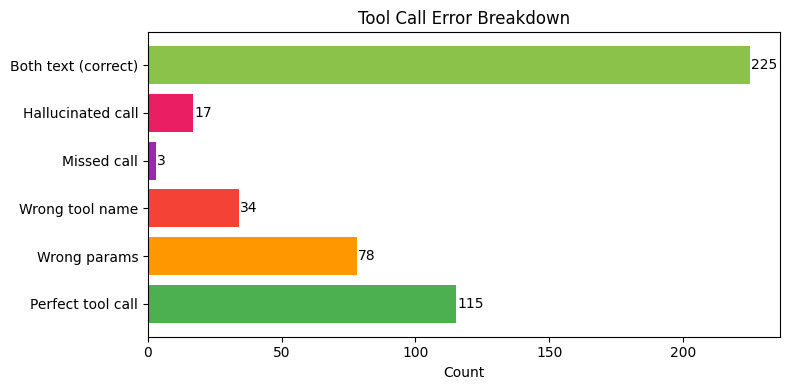

In [12]:
import matplotlib.pyplot as plt

s = q("""
SELECT * FROM (
    VALUES
        ('Perfect tool call',  (SELECT count(*) FROM results WHERE pred_is_tool AND ref_is_tool AND pred_name = ref_name AND pred_params = ref_params)),
        ('Wrong params',       (SELECT count(*) FROM results WHERE pred_is_tool AND ref_is_tool AND pred_name = ref_name AND pred_params != ref_params)),
        ('Wrong tool name',    (SELECT count(*) FROM results WHERE pred_is_tool AND ref_is_tool AND pred_name != ref_name)),
        ('Missed call',        (SELECT count(*) FROM results WHERE ref_is_tool AND NOT pred_is_tool)),
        ('Hallucinated call',  (SELECT count(*) FROM results WHERE NOT ref_is_tool AND pred_is_tool)),
        ('Both text (correct)',(SELECT count(*) FROM results WHERE NOT ref_is_tool AND NOT pred_is_tool))
) t(category, cnt)
""")

colors = ["#4CAF50", "#FF9800", "#F44336", "#9C27B0", "#E91E63", "#8BC34A"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(s.category, s.cnt, color=colors)
for i, v in enumerate(s.cnt):
    ax.text(v + 0.5, i, str(v), va="center")
ax.set_xlabel("Count")
ax.set_title("Tool Call Error Breakdown")
plt.tight_layout()
plt.show()


## 7. Ad-hoc Exploration
Edit the SQL below to drill into any subset you want.

In [13]:
# Example: show all samples where 'time_range' param was wrong
q("""
SELECT idx, question, ref_name AS tool, ref_params, pred_params
FROM results
WHERE wrong_value_keys LIKE '%time_range%'
""")

,idx,question,tool,ref_params,pred_params
0,85,Can I see how much I've spent on takeaway food this month compared to last month?,show_stacked_bar_chart,"{""categories"": [""Restaurants""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 5, ""time_range"": ""last_2_months""}","{""categories"": [""Restaurants""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""payees"": null, ""time_range"": ""this_month""}"
1,107,"Given all the income I've received, can you summarize how much came from regular salary versus occasional bonuses?",show_pie_chart,"{""categories"": [""Salary""], ""data_type"": ""income"", ""group_by"": ""category"", ""time_range"": ""this_year""}","{""categories"": [""Salary"", ""Bonus""], ""data_type"": ""income"", ""group_by"": ""category"", ""time_range"": ""this_month""}"
2,112,Show me a comparison of my shopping and dining out expenses between February and March.,show_stacked_bar_chart,"{""categories"": [""Groceries"", ""Restaurants"", ""Coffee & Bars""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""payees"": null, ""time_range"": ""this_month""}","{""categories"": [""Groceries"", ""Restaurants""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""payees"": null, ""time_range"": ""last_2_months""}"
3,131,"Are there any large transactions that affected my balance recently, and can you break it down for me?",show_pie_chart,"{""data_type"": ""spending"", ""group_by"": ""payee"", ""limit"": 5, ""time_range"": ""this_month""}","{""by_account"": false, ""chart_type"": ""balance"", ""time_range"": ""last_month""}"
4,141,Could you create a bar chart to compare my total expenditure on dining out last month versus this month?,show_stacked_bar_chart,"{""categories"": [""Restaurants""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 1, ""payees"": null, ""time_range"": ""last_month""}","{""categories"": [""Restaurants"", ""Dishoom"", ""Starbucks"", ""Wagamama"", ""Nandos"", ""The Alchemist"", ""Costa Coffee"", ""Dunelm"", ""Tesco"", ""Sainsburys""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""time_range"": ""last_2_months""}"
5,186,I've been trying to figure out if I'm spending too much on groceries. How can I compare my monthly grocery spending?,show_stacked_bar_chart,"{""categories"": [""Groceries""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 5, ""time_range"": ""last_3_months""}","{""by_account"": false, ""chart_type"": ""cash_flow"", ""time_range"": ""this_month""}"
6,225,How can I check if my grocery spending has increased without checking every receipt?,show_line_chart,"{""by_account"": false, ""chart_type"": ""cash_flow"", ""time_range"": ""last_3_months""}","{""by_account"": false, ""chart_type"": ""cash_flow"", ""time_range"": ""this_month""}"
7,237,Can you break down my expenses by category to show me which ones have changed the most recently?,show_pie_chart,"{""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""time_range"": ""last_month""}","{""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 5, ""time_range"": ""last_3_months""}"
8,264,Could you compare my monthly expenditure on entertainment between last month and this month?,show_stacked_bar_chart,"{""categories"": [""Entertainment""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""payees"": null, ""time_range"": ""last_month""}","{""categories"": [""Entertainment""], ""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""time_range"": ""last_2_months""}"
9,265,Can you show me where all my spending went last month?,show_pie_chart,"{""data_type"": ""spending"", ""group_by"": ""category"", ""limit"": 10, ""time_range"": ""this_month""}","{""data_type"": ""spending"", ""group_by"": ""category"", ""time_range"": ""last_month""}"


In [14]:
# Example: show full prediction/reference for a specific sample
q("""
SELECT idx, question, pred_raw, ref_raw
FROM results
WHERE idx = 3
""")

,idx,question,pred_raw,ref_raw
0,3,"I'm thinking of starting a savings goal for a holiday next year, can you help me set it up?","To set up a savings goal for your holiday next year, we can start by estimating how much you need to save each month. Can you tell me approximately how much you think your holiday will cost and when you plan to go? This will help us determine a monthly savings target.","Of course! To set up a savings goal, we first need to estimate how much money you'll need for your holiday. Could you tell me the destination and approximate cost of the holiday? Additionally, when would you like to start saving, and how often do you plan to save? This information will help us determine a realistic monthly savings target."


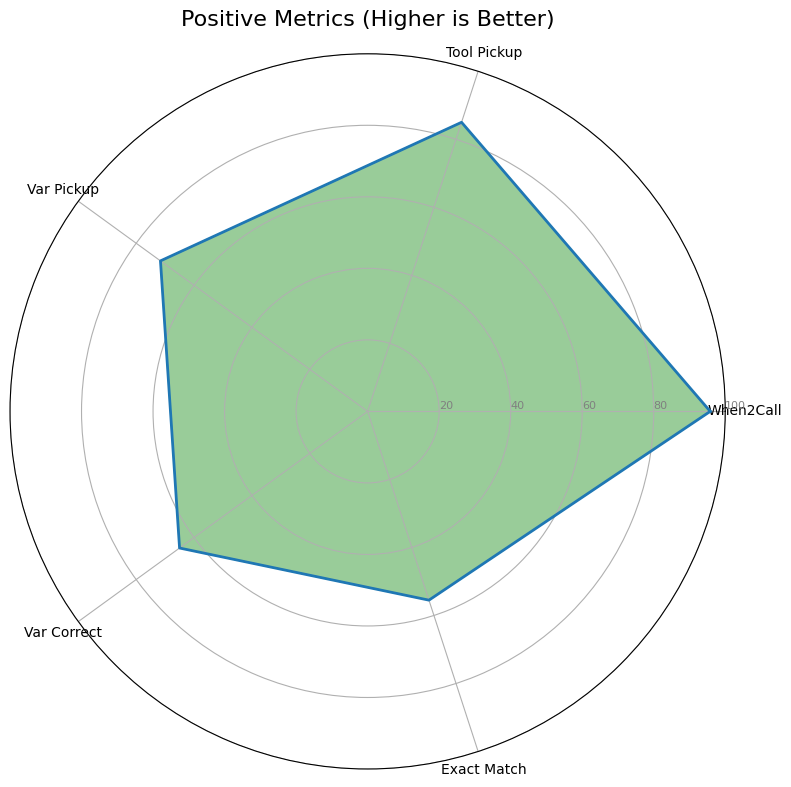

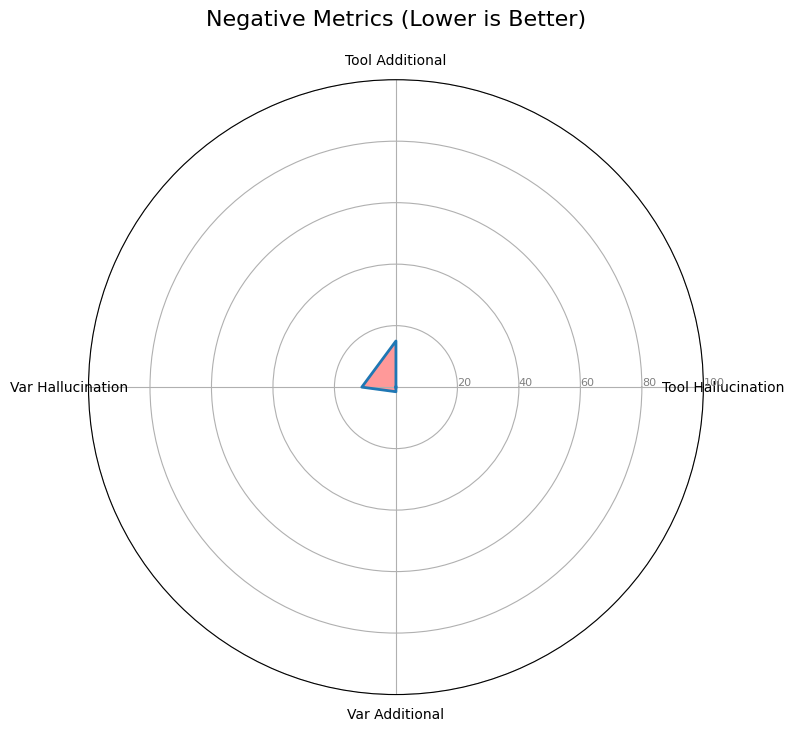

In [22]:
## 8. Radar Plot for Metrics
import matplotlib.pyplot as plt
import numpy as np
import json as _json

# Load results
DATA_FILE = "../output/inference/test_mvp_financial_tool_calling.jsonl"
with open(DATA_FILE) as f:
    results = [_json.loads(l) for l in f]

def is_tool(s):
    try:
        d = _json.loads(s)
        return isinstance(d, dict) and 'name' in d
    except:
        return False

def parse_tool(s):
    try: return _json.loads(s)
    except: return None

total = len(results)
ref_tool = [r for r in results if is_tool(r['reference'])]
ref_text = [r for r in results if not is_tool(r['reference'])]

when2call = sum(1 for r in results if is_tool(r['reference']) == is_tool(r['prediction']))
tool_pickup = sum(1 for r in ref_tool if is_tool(r['prediction']))
tool_halluc = sum(1 for r in ref_text if is_tool(r['prediction']))
exact = sum(1 for r in results if r['prediction'].strip() == r['reference'].strip())

name_correct = 0
param_correct = 0
for r in results:
    ref, pred = parse_tool(r['reference']), parse_tool(r['prediction'])
    if ref and pred and ref.get('name') == pred.get('name'):
        name_correct += 1
        if ref.get('parameters') == pred.get('parameters'):
            param_correct += 1

positive_metrics = {
    'When2Call': 100 * when2call / total,
    'Tool Pickup': 100 * tool_pickup / len(ref_tool) if ref_tool else 0,
    'Name Correct': 100 * name_correct / tool_pickup if tool_pickup else 0,
    'Param Correct': 100 * param_correct / name_correct if name_correct else 0,
    'Exact Match': 100 * exact / total,
}

negative_metrics = {
    'Tool Hallucination': 100 * tool_halluc / len(ref_text) if ref_text else 0,
    'Missed Tool': 100 * (len(ref_tool) - tool_pickup) / len(ref_tool) if ref_tool else 0,
    'Wrong Name': 100 * (tool_pickup - name_correct) / tool_pickup if tool_pickup else 0,
    'Wrong Params': 100 * (name_correct - param_correct) / name_correct if name_correct else 0,
}

print(f"Total: {total} (tool: {len(ref_tool)}, text: {len(ref_text)})")
for k, v in {**positive_metrics, **negative_metrics}.items():
    print(f"  {k}: {v:.1f}%")

def plot_radar(labels, stats, title, color='blue'):
    N = len(labels)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    stats += stats[:1]
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    plt.xticks(angles[:-1], labels, fontsize=10)
    ax.set_rlabel_position(0)
    plt.yticks([20, 40, 60, 80, 100], ["20", "40", "60", "80", "100"], color="grey", size=8)
    plt.ylim(0, 100)
    ax.plot(angles, stats, linewidth=2, linestyle='solid')
    ax.fill(angles, stats, alpha=0.4, color=color)
    plt.title(title, size=16, pad=20)
    plt.tight_layout()
    plt.show()

plot_radar(list(positive_metrics.keys()), list(positive_metrics.values()), 'Positive Metrics (Higher is Better)', color='green')
plot_radar(list(negative_metrics.keys()), list(negative_metrics.values()), 'Negative Metrics (Lower is Better)', color='red')
